In [1]:
import win32com.client
import time
import os
from datetime import datetime

def run_all_bloomberg_updates():
    # 1. Single Date Input
    date_input = input("Enter the date for all updates (yyyymmdd): ")
    results_summary = []
    
    try:
        # Date transformations
        dt_obj = datetime.strptime(date_input, '%Y%m%d')
        bql_date = dt_obj.strftime('%Y-%m-%d')        
        excel_date = dt_obj.strftime('%#m/%d/%Y')     
        
        # Define Paths
        neg_sel_dir = r"C:\Users\B420615\OneDrive - Standard Bank\Neg_Sel"
        add_data_path = r"C:\Users\B420615\OneDrive - Standard Bank\Py\AdditionalData.csv"
        jalsh_path = r"C:\Users\B420615\OneDrive - Standard Bank\Py\JalshWeightsBBG.csv"
        new_ns_file = os.path.join(neg_sel_dir, f"NS{date_input}.csv")

        # 2. Start Excel
        excel = win32com.client.Dispatch("Excel.Application")
        excel.Visible = True 

        # --- PREP TASK 1 ---
        print("Prepping Task 1: New Negative Selection file...")
        wb1 = excel.Workbooks.Add()
        ws1 = wb1.Worksheets(1)
        ws1.Range("B1").Formula = f'=beqs("Negative_Selection","AsOf={date_input}")'

        # --- PREP TASK 2 ---
        print("Prepping Task 2: Appending to Additional Data...")
        wb2 = excel.Workbooks.Open(add_data_path)
        ws2 = wb2.Worksheets(1)
        start_row2 = ws2.Cells(ws2.Rows.Count, "B").End(-4162).Row
        insert_row2 = start_row2 + 1
        ws2.Cells(insert_row2, 2).Formula = f'=beqs("NS_add_data","AsOf={date_input}")'

        # --- PREP TASK 3 ---
        print("Prepping Task 3: Appending JALSH Weights...")
        wb3 = excel.Workbooks.Open(jalsh_path)
        ws3 = wb3.Worksheets(1)
        start_row3 = ws3.Cells(ws3.Rows.Count, "B").End(-4162).Row
        insert_row3 = start_row3 + 1
        jalsh_formula = f'=@BQL("members(\'JALSH Index\', dates={bql_date})", "weights, ID_BB_GLOBAL,classification_name")'
        ws3.Cells(insert_row3, 2).Formula = jalsh_formula

        # 3. Wait for Bloomberg
        wait_time = 45
        print(f"Waiting {wait_time} seconds for data to populate...")
        time.sleep(wait_time) 

        # 4. Finalize Task 1
        last_row1 = ws1.Cells(ws1.Rows.Count, "B").End(-4162).Row
        rows_added1 = max(0, last_row1 - 1)
        if last_row1 > 1:
            ws1.Range("A1").Value = "Date"
            ws1.Range(f"A2:A{last_row1}").Value = date_input
        wb1.SaveAs(new_ns_file, FileFormat=6)
        wb1.Close()
        results_summary.append(f"Task 1 (New NS File): Created with {rows_added1} rows.")

        # 5. Finalize Task 2
        last_row2 = ws2.Cells(ws2.Rows.Count, "B").End(-4162).Row
        if last_row2 >= insert_row2:
            ws2.Range(ws2.Cells(insert_row2, 1), ws2.Cells(last_row2, 1)).Value = date_input
            ws2.Rows(insert_row2).Delete()
            rows_added2 = last_row2 - insert_row2 # Since we deleted 1 header row
        else:
            rows_added2 = 0
        wb2.Save()
        wb2.Close()
        results_summary.append(f"Task 2 (Add Data Master): Appended {rows_added2} rows.")

        # 6. Finalize Task 3
        last_row3 = ws3.Cells(ws3.Rows.Count, "B").End(-4162).Row
        if last_row3 >= insert_row3:
            ws3.Range(ws3.Cells(insert_row3, 1), ws3.Cells(last_row3, 1)).Value = excel_date
            ws3.Rows(insert_row3).Delete()
            rows_added3 = last_row3 - insert_row3
        else:
            rows_added3 = 0
        wb3.Save()
        wb3.Close()
        results_summary.append(f"Task 3 (JALSH Weights): Appended {rows_added3} rows.")

        # --- FINAL SUMMARY ---
        print("\n" + "="*30)
        print("UPDATE COMPLETE SUMMARY")
        print("="*30)
        for line in results_summary:
            print(line)

    except Exception as e:
        print(f"An error occurred: {e}")
    finally:
        print("\nAll workbooks processed.")

if __name__ == "__main__":
    run_all_bloomberg_updates()

Enter the date for all updates (yyyymmdd):  20260228


Prepping Task 1: New Negative Selection file...
Prepping Task 2: Appending to Additional Data...
Prepping Task 3: Appending JALSH Weights...
Waiting 45 seconds for data to populate...

UPDATE COMPLETE SUMMARY
Task 1 (New NS File): Created with 119 rows.
Task 2 (Add Data Master): Appended 119 rows.
Task 3 (JALSH Weights): Appended 120 rows.

All workbooks processed.


In [4]:
import numpy as np
import pandas as pd
import glob
import os
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy.stats import zscore
from scipy import stats
from pathlib import Path
import warnings # Import the warnings module
from itertools import combinations
pd.set_option('future.no_silent_downcasting', True)

In [6]:
# Configuration
jalsh_file = 'JalshWeightsBBG.csv'
add_data_file = 'AdditionalData.csv'
output_file = 'merged_ns_jalsh.csv'
ns_pattern = r'C:\Users\B420615\OneDrive - Standard Bank\Neg_Sel\NS*.csv'
ns_columns_to_drop = ['Market Cap', 'Last Px']
add_columns_to_drop = ['Short Name', 'Market Cap', 'Price:D-1']

# ============================================================
# STEP 1: Find the latest NS file
# ============================================================
print('1. Finding latest NS file...')
ns_files = sorted(glob.glob(ns_pattern))
if not ns_files:
    raise FileNotFoundError(f'No NS files found matching: {ns_pattern}')

latest_ns_file = ns_files[-1]
filename = os.path.basename(latest_ns_file)
date_str = filename.replace('NS', '').replace('.csv', '')
ns_latest_date = int(date_str)   # e.g. 20260131
print(f'   Latest NS file : {filename}  (date: {ns_latest_date})')

# ============================================================
# STEP 2: Load source files and determine their latest dates
# ============================================================
print('\n2. Checking latest dates in source files...')

# --- JalshWeightsBBG ---
print(f'   Reading {jalsh_file}...')
jalsh_df_full = pd.read_csv(jalsh_file)
jalsh_df_full = jalsh_df_full.rename(columns={'ID': 'Ticker', 'id().weights': 'Weight'})

def convert_jalsh_date(d):
    try:
        return int(pd.to_datetime(d).strftime('%Y%m%d'))
    except:
        return None

jalsh_df_full['Date'] = jalsh_df_full['Date'].apply(convert_jalsh_date)
jalsh_latest_date = int(jalsh_df_full['Date'].max())
print(f'   Latest date in JalshWeightsBBG.csv : {jalsh_latest_date}')

# --- AdditionalData ---
print(f'   Reading {add_data_file}...')
add_data_full = pd.read_csv(add_data_file)
add_data_full['Date'] = pd.to_numeric(add_data_full['Date'], errors='coerce')
add_latest_date = int(add_data_full['Date'].max())
print(f'   Latest date in AdditionalData.csv  : {add_latest_date}')

# ============================================================
# STEP 3: Check the latest date already present in merged file
# ============================================================
print(f'\n3. Loading existing {output_file}...')
existing_df = pd.read_csv(output_file)
existing_df['Date'] = pd.to_numeric(existing_df['Date'], errors='coerce')
existing_latest_date = int(existing_df['Date'].max())
print(f'   Rows in existing file          : {len(existing_df):,}')
print(f'   Latest date in merged file     : {existing_latest_date}')

# ============================================================
# STEP 4: Incremental update (only if the NS file is newer)
# ============================================================
if ns_latest_date <= existing_latest_date:
    print(f'\n\u2713 No update needed. Latest NS date ({ns_latest_date}) already present in merged file.')
    print('  Downstream cells will re-process the existing data.')
else:
    print(f'\n4. New date {ns_latest_date} detected – starting incremental update...')

    # Warn if a source file lags behind the NS date
    if ns_latest_date > jalsh_latest_date:
        print(f'   \u26a0 WARNING: NS date {ns_latest_date} is newer than JalshWeightsBBG latest ({jalsh_latest_date})')
    if ns_latest_date > add_latest_date:
        print(f'   \u26a0 WARNING: NS date {ns_latest_date} is newer than AdditionalData latest ({add_latest_date})')

    # ------------------------------------------------------------------
    # 4a. Slice each source to the new date only
    # ------------------------------------------------------------------
    jalsh_new = jalsh_df_full[jalsh_df_full['Date'] == ns_latest_date].copy()
    print(f'   Jalsh rows for {ns_latest_date}         : {len(jalsh_new)}')

    print(f'   Reading NS file: {filename}')
    ns_new = pd.read_csv(latest_ns_file)
    for col in ns_columns_to_drop:
        if col in ns_new.columns:
            ns_new = ns_new.drop(columns=[col])
    cols_to_conv = ns_new.columns[3:]
    for col in cols_to_conv:
        ns_new[col] = pd.to_numeric(ns_new[col], errors='coerce')
    ns_new['Date'] = pd.to_numeric(ns_new['Date'], errors='coerce')
    print(f'   NS rows                          : {len(ns_new)}')

    add_new = add_data_full[add_data_full['Date'] == ns_latest_date].copy()
    add_new = add_new.drop(columns=[c for c in add_columns_to_drop if c in add_new.columns])
    for col in add_new.columns[2:]:
        add_new[col] = pd.to_numeric(add_new[col], errors='coerce')
    print(f'   AdditionalData rows for {ns_latest_date}: {len(add_new)}')

    # ------------------------------------------------------------------
    # 4b. Standardise ticker names
    # ------------------------------------------------------------------
    ticker_map = {'AU US Equity': 'ANG SJ Equity', '2251506D SJ Equity': 'CFR SJ Equity'}
    for df_ref in [jalsh_new, ns_new, add_new]:
        for old_tk, new_tk in ticker_map.items():
            mask = df_ref['Ticker'] == old_tk
            if mask.any():
                df_ref.loc[mask, 'Ticker'] = new_tk

    # ------------------------------------------------------------------
    # 4c. Merge the three slices (same logic as original full merge)
    # ------------------------------------------------------------------
    new_merged = (
        jalsh_new
        .merge(ns_new,  on=['Date', 'Ticker'], how='outer', suffixes=('_jalsh', '_ns'))
        .merge(add_new, on=['Date', 'Ticker'], how='outer', suffixes=('_comb',  '_add'))
    )
    new_merged = new_merged.sort_values(['Date', 'Ticker']).reset_index(drop=True)

    # Flip BENEISH-M sign so higher = better (consistent with all other factors)
    new_merged['BENEISH-M'] = pd.to_numeric(
        new_merged['BENEISH-M'].replace(['N.A.', '-', '', ' '], np.nan), errors='coerce'
    ) * -1

    print(f'   Merged rows for new date         : {len(new_merged)}')

    # ------------------------------------------------------------------
    # 4d. Align columns to exactly match the existing merged file
    # ------------------------------------------------------------------
    expected_cols = existing_df.columns.tolist()
    for col in expected_cols:
        if col not in new_merged.columns:
            new_merged[col] = np.nan                 # pad any missing columns
    new_merged = new_merged[expected_cols]            # enforce column order

    # ------------------------------------------------------------------
    # 4e. Safety: remove any pre-existing rows for this date
    # ------------------------------------------------------------------
    existing_df = existing_df[existing_df['Date'] != ns_latest_date]

    # ------------------------------------------------------------------
    # 4f. Concatenate, sort, and save
    # ------------------------------------------------------------------
    updated_df = pd.concat([existing_df, new_merged], ignore_index=True)
    updated_df = updated_df.sort_values(['Date', 'Ticker']).reset_index(drop=True)
    updated_df.to_csv(output_file, index=False)

    print(f'\n{"="*60}')
    print('INCREMENTAL UPDATE COMPLETE!')
    print(f'{"="*60}')
    print(f'  New rows appended    : {len(new_merged)}')
    print(f'  Total rows in file   : {len(updated_df):,}')
    print(f'  Date range           : {int(updated_df["Date"].min())} to {int(updated_df["Date"].max())}')
    print(f'  Unique tickers       : {updated_df["Ticker"].nunique()}')

1. Finding latest NS file...
   Latest NS file : NS20260228.csv  (date: 20260228)

2. Checking latest dates in source files...
   Reading JalshWeightsBBG.csv...
   Latest date in JalshWeightsBBG.csv : 20260228
   Reading AdditionalData.csv...
   Latest date in AdditionalData.csv  : 20260228

3. Loading existing merged_ns_jalsh.csv...
   Rows in existing file          : 40,220
   Latest date in merged file     : 20260228

✓ No update needed. Latest NS date (20260228) already present in merged file.
  Downstream cells will re-process the existing data.


In [4]:
"""
Create a new column that reflects returns/performance achieved alongside factor variables

"""

# Load your data
df = pd.read_csv(r"C:\Users\B420615\OneDrive - Standard Bank\Py\merged_ns_jalsh.csv")





#Ensure dates in correct format
df['Date'] = pd.to_datetime(df['Date'], format='%Y%m%d')

print(f"Date range before processing: {df['Date'].min()} to {df['Date'].max()}")

# Sort by Ticker and Date for the shift operation
df = df.sort_values(['Ticker', 'Date'])

# Create FR column: each row gets the NEXT month's TR_1M value for that ticker
df['FR'] = df.groupby('Ticker')['Total Return:M-1'].shift(-1)

# Re-sort by Date (and Ticker) to restore original order
df = df.sort_values(['Date', 'Ticker'])

# Reset index to clean up
df = df.reset_index(drop=True)


print(f"Date range after processing: {df['Date'].min()} to {df['Date'].max()}")
print(f"Forward returns created: {df['FR'].notna().sum():,} / {len(df):,}")

# Save with proper date format
df.to_csv(r"C:\Users\B420615\OneDrive - Standard Bank\Py\merged_ns_jalsh_FR.csv", index=False, date_format='%Y-%m-%d')

print("\nFirst few dates to verify:")
print(df[['Date', 'Ticker', 'Total Return:M-1', 'FR']].head(10))

Date range before processing: 2004-12-31 00:00:00 to 2026-02-28 00:00:00
Date range after processing: 2004-12-31 00:00:00 to 2026-02-28 00:00:00
Forward returns created: 38,910 / 40,220

First few dates to verify:
        Date              Ticker  Total Return:M-1     FR
0 2004-12-31  0861674D SJ Equity             -0.47   5.16
1 2004-12-31       ABG SJ Equity              9.40   0.53
2 2004-12-31       ACL SJ Equity              0.48  -7.17
3 2004-12-31       ACP SJ Equity              7.86  -1.81
4 2004-12-31       ADH SJ Equity             -6.25   5.83
5 2004-12-31       ADR SJ Equity              1.50  14.50
6 2004-12-31       AEG SJ Equity              2.13  -5.42
7 2004-12-31       AEL SJ Equity             -0.06   0.30
8 2004-12-31       AEN SJ Equity               NaN    NaN
9 2004-12-31       AFE SJ Equity              5.41   5.13


In [5]:
#create two lists of desired column names - one for all columns and one for data columns
adjcols = ['Date','Ticker','Name','BM','AdjfcfY','CECP','TR_1M','Price','FCFY','MCap','TR_12-1','best_eps_chg','rec_chg12M','tp_chg','fcf_me','fcf_at','seas_1_1an','rec_chg']
data_cols = ['BM','AdjfcfY','CECP','TR_1M','FCFY','TR_12-1','best_eps_chg','rec_chg12M','tp_chg','fcf_me','fcf_at','seas_1_1an','rec_chg','dc','tr_comb','tr_beta']
cols_with_commas = ['Price','MCap']
cols_to_avg = ['BM','AdjfcfY','TR_1M','FCFY','TR_12-1','best_eps_chg','rec_chg12M','tp_chg','fcf_me','fcf_at','seas_1_1an']
cols_to_zero = ['CECP']
excl_cols = ['rec_chg']

In [6]:
"""
Re-name columns with names that are easier to work with
Calculate Z-Scores for all columns

"""
# clean data so that all values, apart from naming values, and including NaNs, are reflected as float values. Delete unneeded column
neg_sel_df = pd.read_csv(r"C:\Users\B420615\OneDrive - Standard Bank\Py\merged_ns_jalsh_FR.csv")
               
column_mapping = {
    'Date': 'Date',
    'Ticker': 'Ticker',
    'Short Name': 'Name',
    'BENEISH-M': 'BM',
    'AdjFCFYield': 'AdjfcfY',
    'ChgEstimateVSChgPrice': 'CECP',
    'Total Return:M-1': 'TR_1M',
    'FCF Yld:Y': 'FCFY',
    'TR_Momentum': 'TR_12-1',
    'best_eps_chg': 'best_eps_chg',
    'rec_chg_12M': 'rec_chg12M',
    'tp_change': 'tp_chg',
    'fcf_me': 'fcf_me',
    'fcf_at': 'fcf_at',
    'seas_1_1an': 'seas_1_1an',
    'rec_chg': 'rec_chg',
    'Market Cap': 'MCap',
    'Last Px': 'Price',
    'death_cross': 'dc',
    'p_rel_52wH': 'prelH',
    'tr_combined': 'tr_comb',
    'tr_residualbeta2yrxD': 'tr_beta'
}
# Rename columns
neg_sel_df = neg_sel_df.rename(columns=column_mapping)

#Ensure all values are floats
for col in data_cols:
    neg_sel_df[col] = pd.to_numeric(neg_sel_df[col], errors='coerce')

neg_sel_df = neg_sel_df.sort_values('Date')

for col in data_cols:
    neg_sel_df[f'{col}_z'] = neg_sel_df.groupby('Date')[col].transform(
    lambda x: (x - x.mean()) / x.std() if x.std() != 0 else 0
    )
    
    
neg_sel_df.head()



,Date,Ticker,Weight,ID_BB_GLOBAL,BICS1,Name,BM,AdjfcfY,CECP,TR_1M,...,best_eps_chg_z,rec_chg12M_z,tp_chg_z,fcf_me_z,fcf_at_z,seas_1_1an_z,rec_chg_z,dc_z,tr_comb_z,tr_beta_z
0,2004-12-31,0861674D SJ Equity,0.280880,BBG000C2WKK9,Financials,ALEXANDER FORBES,NaN,0.00,NaN,-0.47,...,NaN,-0.819135,-0.325026,-0.372139,-0.224941,-0.268065,-0.713494,-0.687125,-0.842540,-0.822428
105,2004-12-31,NTC SJ Equity,0.475897,BBG000BLCYS2,Health Care,NETCARE LTD,2.18,0.01,NaN,-4.36,...,NaN,-1.380761,-0.178237,-0.137104,0.013885,-0.949585,-1.377782,-0.475424,-0.652662,-0.691410
106,2004-12-31,NWL SJ Equity,0.031570,BBG000BFLGW9,Consumer Discretionary,NU-WORLD HLDGS,2.48,0.09,NaN,6.58,...,NaN,NaN,NaN,NaN,NaN,-0.469208,NaN,0.724218,0.625046,0.498668
107,2004-12-31,OCE SJ Equity,0.037350,BBG000BSD7T4,Consumer Staples,OCEANA GROUP LTD,2.26,-0.01,NaN,-2.30,...,NaN,-2.212801,NaN,NaN,NaN,0.181549,-2.330891,-1.039961,-0.917264,-0.887937
108,2004-12-31,OCT SJ Equity,0.028646,BBG000BFLKR6,Real Estate,OCTODEC INVESTME,1.90,0.06,NaN,6.56,...,NaN,NaN,NaN,NaN,NaN,-1.528562,NaN,0.300815,-0.002166,0.196599


In [7]:
# ============================================================
# APPLY LIQUIDITY FILTER
# ============================================================
print("\n" + "="*80)
print("APPLYING LIQUIDITY FILTER (Weight >= 0.25%)")
print("="*80)

min_weight = 0.25  # 0.25% of index

# Convert Weight to numeric (coerce errors to NaN)
neg_sel_df['Weight'] = pd.to_numeric(neg_sel_df['Weight'], errors='coerce')

# Check weight distribution before filtering
print(f"\nWeight distribution before filtering:")
print(neg_sel_df['Weight'].describe())

# Apply filter
df_liquid = neg_sel_df[neg_sel_df['Weight'] >= min_weight].copy()

print(f"\nAfter liquidity filter:")
print(f"  Observations removed: {len(neg_sel_df) - len(df_liquid):,} ({100*(len(neg_sel_df) - len(df_liquid))/len(neg_sel_df):.1f}%)")
print(f"  Observations remaining: {len(df_liquid):,} ({100*len(df_liquid)/len(neg_sel_df):.1f}%)")

# Check stocks per month
stocks_per_month_before = df_liquid.groupby('Date').size()
stocks_per_month_after = df_liquid.groupby('Date').size()

print(f"\nStocks per month:")
print(f"  Before filter: {stocks_per_month_before.mean():.1f} avg (min: {stocks_per_month_before.min()}, max: {stocks_per_month_before.max()})")
print(f"  After filter:  {stocks_per_month_after.mean():.1f} avg (min: {stocks_per_month_after.min()}, max: {stocks_per_month_after.max()})")

# Save processed sentiment csv file
output_file_path = 'df_liquid_with_zScores.csv'
df_liquid.to_csv(output_file_path, index=False)



APPLYING LIQUIDITY FILTER (Weight >= 0.25%)

Weight distribution before filtering:
count    39821.000000
mean         0.640381
std          1.635285
min          0.000000
25%          0.050659
50%          0.140953
75%          0.491318
max         20.995337
Name: Weight, dtype: float64

After liquidity filter:
  Observations removed: 25,351 (63.0%)
  Observations remaining: 14,869 (37.0%)

Stocks per month:
  Before filter: 58.3 avg (min: 43, max: 69)
  After filter:  58.3 avg (min: 43, max: 69)


DUAL COMPOSITE LONG/SHORT PORTFOLIO ANALYSIS

Loading data...
Loaded 14,869 rows
Date range: 2004-12-31 00:00:00 to 2026-02-28 00:00:00
Using FR (Forward Return) column for all return calculations
FR stats: mean=1.31%, std=9.21%
Data initialized: 14,811 rows, 254 months
Return column: FR (mean=1.31%)

OVERLAP ELIMINATION: Found 64 instances across 57 months
  These stocks appear in BOTH Long Q5 and Short Q1 in the same month
  Excluding them from BOTH portfolios...
  Most frequent overlap stocks:
    ANG SJ Equity: 11 times
    HAR SJ Equity: 6 times
    NTC SJ Equity: 5 times
    SSW SJ Equity: 4 times
    IMP SJ Equity: 4 times


QUINTILE PERFORMANCE

LONG Composite (Q5 = stocks to buy):
  Q1: CAGR=  4.14%, Sharpe=0.30, MaxDD=-65.4%
  Q2: CAGR= 11.69%, Sharpe=0.77, MaxDD=-34.1%
  Q3: CAGR= 13.90%, Sharpe=0.92, MaxDD=-41.2%
  Q4: CAGR= 15.90%, Sharpe=0.94, MaxDD=-38.9%
  Q5: CAGR= 33.87%, Sharpe=1.66, MaxDD=-22.9%

SHORT Composite (Q1 = stocks to avoid/short):
  Q1: CAGR=  4.78%, Shar

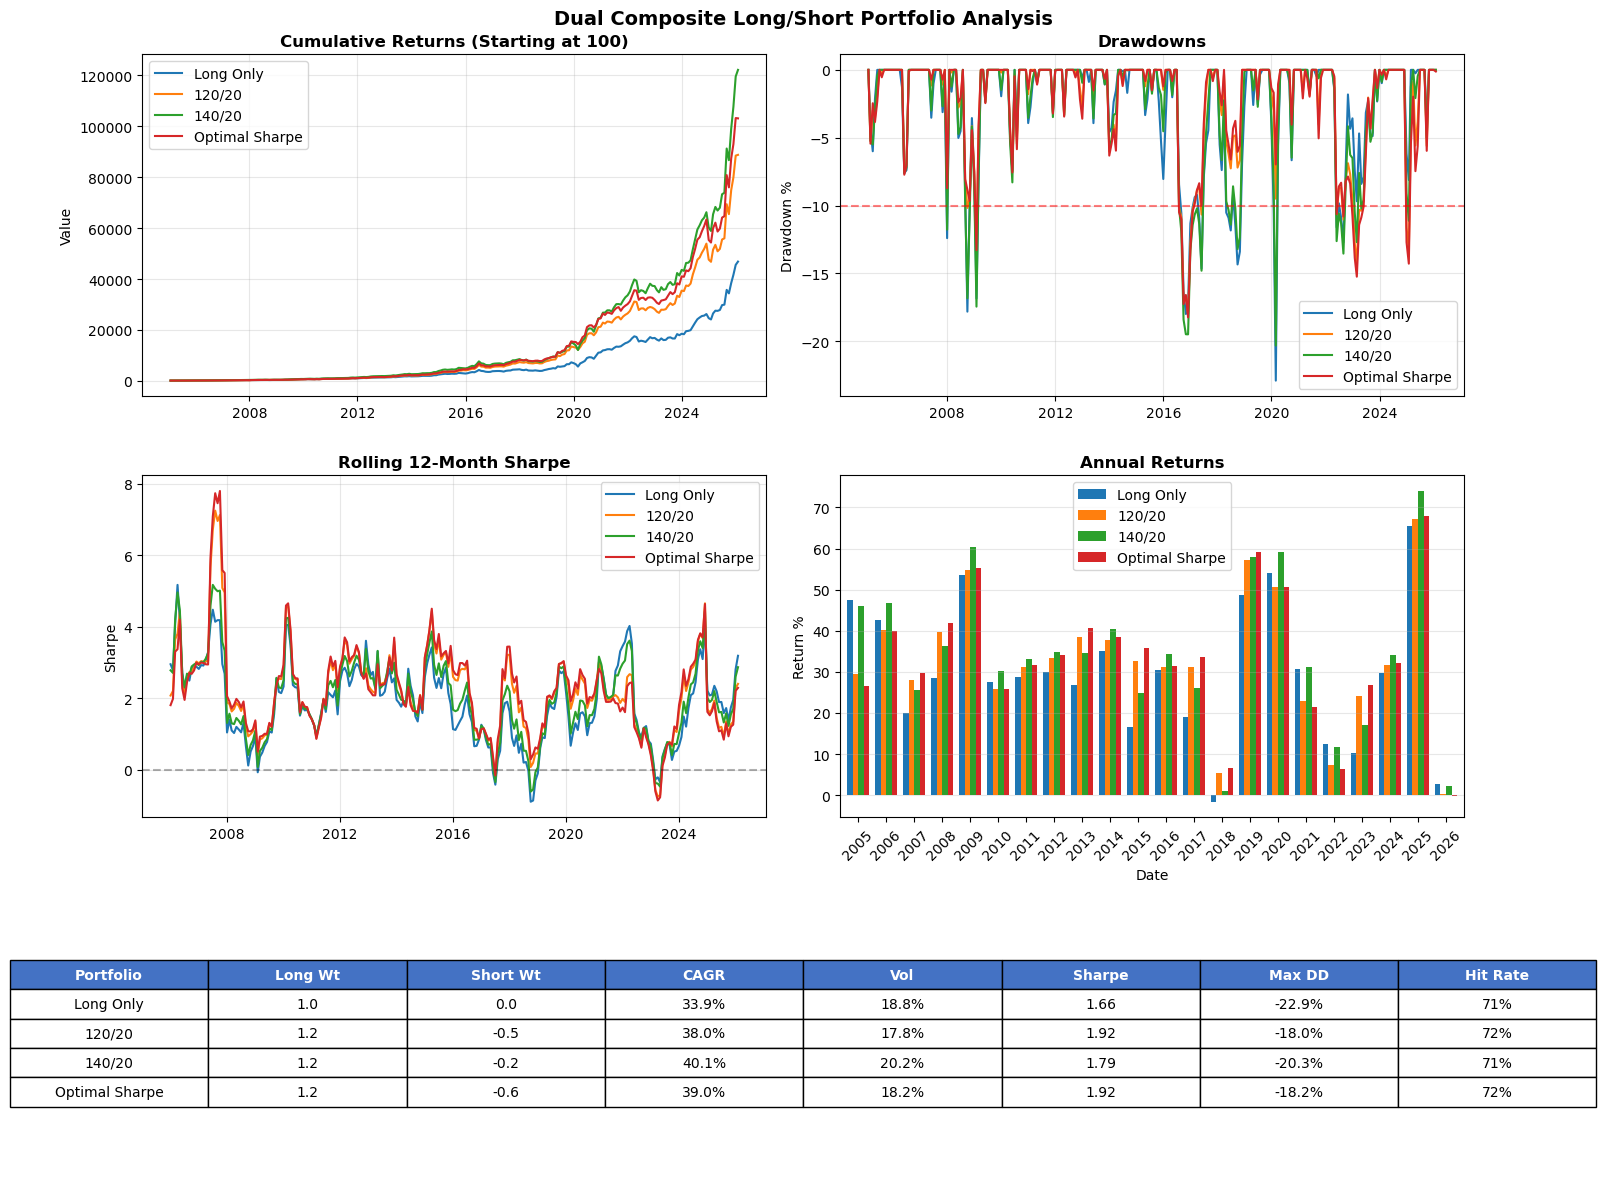

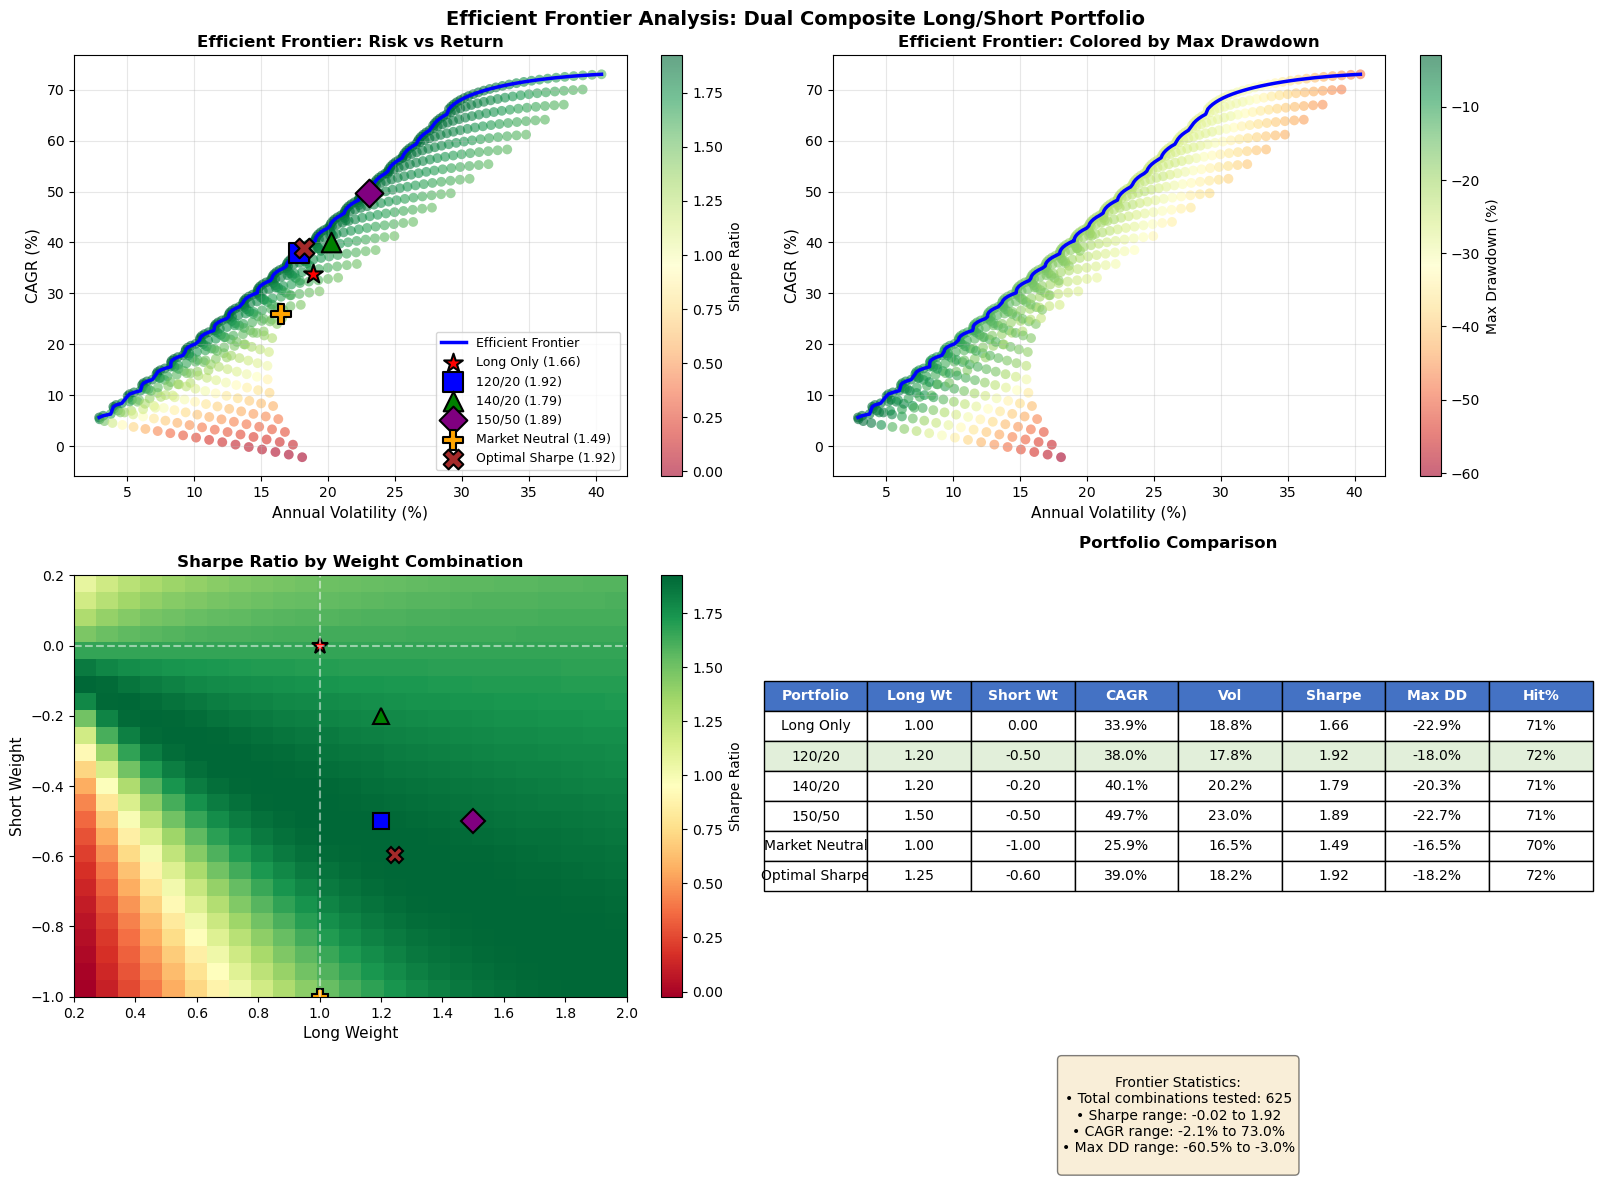

In [2]:
"""
Enhanced Dual Composite Long/Short Portfolio Analysis
======================================================
Data Source: df_liquid_with_zScores.csv
Return Column: FR (Forward Return)

Supports different factor compositions for long (Q5) and short (Q1) positions,
flexible weighting, optimal weight discovery, and drawdown constraints.

Key Features:
1. Define separate factor sets for long and short composites
2. Combine Q5 from long composite with Q1 from short composite
3. Variable weighting (e.g., 1.2x Q5, -0.2x Q1)
4. Optimal historical weight discovery
5. Drawdown-constrained optimization
6. Efficient frontier analysis
7. OVERLAP ELIMINATION: Stocks appearing in both Long Q5 and Short Q1 
   in the same month are excluded from BOTH portfolios

All returns calculated using FR (Forward Return) column.
"""

import numpy as np
import pandas as pd
from scipy import stats
from scipy.optimize import minimize, minimize_scalar, brute
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')


class DualCompositePortfolio:
    """
    A class for constructing and analyzing long/short portfolios
    using dual composite factors.
    
    OVERLAP HANDLING: When a stock appears in both Long Q5 and Short Q1
    in the same month, it is excluded from BOTH portfolios to avoid
    conflicting signals.
    """
    
    def __init__(self, df, start_date='2005-01-01', end_date='2026-02-28', return_col='FR'):
        """
        Initialize with data.
        
        Parameters:
        -----------
        df : DataFrame - Data containing z-scored factors and return column
        start_date : str - Start date for analysis
        end_date : str - End date for analysis
        return_col : str - Column name for returns (default: 'FR' for Forward Return)
        """
        # Validate return column exists
        if return_col not in df.columns:
            raise ValueError(f"Return column '{return_col}' not found in data. "
                           f"Available columns: {list(df.columns)}")
        
        self.return_col = return_col
        self.df_original = df.copy()
        self.df = df[(df['Date'] >= start_date) & (df['Date'] <= end_date)].copy()
        self.start_date = start_date
        self.end_date = end_date
        
        self.long_monthly = None
        self.short_monthly = None
        self.long_factors = None
        self.short_factors = None
        
        # Track overlap statistics
        self.overlap_count = 0
        self.months_with_overlap = 0
        
        # Print data summary
        print(f"Data initialized: {len(self.df):,} rows, {self.df['Date'].nunique()} months")
        print(f"Return column: {return_col} (mean={self.df[return_col].mean():.2f}%)")
        
    def _zscore_monthly(self, group):
        """Z-score within each month."""
        if len(group) < 3:
            return pd.Series([np.nan] * len(group), index=group.index)
        mean, std = group.mean(), group.std()
        if std == 0 or np.isnan(std):
            return pd.Series([0.0] * len(group), index=group.index)
        return (group - mean) / std
    
    def _create_quintiles(self, group):
        """Assign quintiles within each month."""
        if len(group) < 5:
            return pd.Series([np.nan] * len(group), index=group.index)
        try:
            return pd.qcut(group, q=5, labels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5'], duplicates='drop')
        except:
            return pd.Series([np.nan] * len(group), index=group.index)
    
    def set_long_factors(self, factors_dict):
        """
        Set factors and weights for the LONG composite (Q5).
        
        Parameters:
        -----------
        factors_dict : dict
            e.g., {'CECP_z': 0.2, 'tp_chg_z': 0.2, 'rec_chg_z': 0.2, ...}
        """
        self.long_factors = factors_dict
        self._build_composite('long', factors_dict)
        
        # If short factors already set, eliminate overlaps and recalculate
        if self.short_factors is not None:
            self._eliminate_overlaps_and_recalculate()
        
    def set_short_factors(self, factors_dict):
        """
        Set factors and weights for the SHORT composite (Q1).
        Can be different from long factors to optimize for shorting.
        
        Parameters:
        -----------
        factors_dict : dict
            e.g., {'BM_z': -0.3, 'fcf_me_z': 0.2, ...}
        """
        self.short_factors = factors_dict
        self._build_composite('short', factors_dict)
        
        # If long factors already set, eliminate overlaps and recalculate
        if self.long_factors is not None:
            self._eliminate_overlaps_and_recalculate()
    
    def _build_composite(self, name, factors_dict):
        """Build composite z-score and assign quintiles (but don't calculate returns yet)."""
        # Create raw composite
        composite = pd.Series(0.0, index=self.df.index)
        for factor, weight in factors_dict.items():
            if factor in self.df.columns:
                composite += self.df[factor].fillna(0) * weight
            else:
                print(f"WARNING: Factor {factor} not found")
        
        self.df[f'{name}_raw'] = composite
        
        # Standardize within month
        self.df[f'{name}_z'] = self.df.groupby('Date')[f'{name}_raw'].transform(self._zscore_monthly)
        
        # Assign quintiles and store in dataframe
        self.df[f'{name}_quintile'] = self.df.groupby('Date')[f'{name}_z'].transform(self._create_quintiles)
    
    def _eliminate_overlaps_and_recalculate(self):
        """
        Identify stocks that appear in both Long Q5 and Short Q1 in the same month,
        exclude them from BOTH portfolios, and recalculate quintile returns.
        """
        # Get valid data
        df_valid = self.df.dropna(subset=['long_z', 'short_z', self.return_col, 
                                          'long_quintile', 'short_quintile']).copy()
        
        # Identify overlaps: stocks in Long Q5 AND Short Q1 in same month
        df_valid['is_long_q5'] = df_valid['long_quintile'] == 'Q5'
        df_valid['is_short_q1'] = df_valid['short_quintile'] == 'Q1'
        df_valid['is_overlap'] = df_valid['is_long_q5'] & df_valid['is_short_q1']
        
        # Count overlaps
        self.overlap_count = df_valid['is_overlap'].sum()
        self.months_with_overlap = (df_valid.groupby('Date')['is_overlap'].sum() > 0).sum()
        
        if self.overlap_count > 0:
            print(f"\nOVERLAP ELIMINATION: Found {self.overlap_count} instances across {self.months_with_overlap} months")
            print(f"  These stocks appear in BOTH Long Q5 and Short Q1 in the same month")
            print(f"  Excluding them from BOTH portfolios...")
        
        # Create copy for overlap-free calculations
        df_no_overlap = df_valid.copy()
        
        # Set quintiles to NaN for overlapping stocks (excludes them from both sides)
        df_no_overlap.loc[df_no_overlap['is_overlap'], 'long_quintile'] = np.nan
        df_no_overlap.loc[df_no_overlap['is_overlap'], 'short_quintile'] = np.nan
        
        # Recalculate quintile returns WITHOUT overlapping stocks
        # Long composite
        long_valid = df_no_overlap.dropna(subset=['long_quintile'])
        self.long_monthly = long_valid.groupby(
            ['Date', 'long_quintile'], observed=True)[self.return_col].mean().unstack()
        
        # Short composite
        short_valid = df_no_overlap.dropna(subset=['short_quintile'])
        self.short_monthly = short_valid.groupby(
            ['Date', 'short_quintile'], observed=True)[self.return_col].mean().unstack()
        
        if self.overlap_count > 0:
            # Show most frequent overlap stocks
            overlap_stocks = df_valid[df_valid['is_overlap']]
            if 'Ticker' in overlap_stocks.columns:
                top_overlaps = overlap_stocks['Ticker'].value_counts().head(5)
                print(f"  Most frequent overlap stocks:")
                for ticker, count in top_overlaps.items():
                    print(f"    {ticker}: {count} times")
            print()
    
    def get_combined_returns(self, long_weight=1.0, short_weight=0.0,
                            long_quintile='Q5', short_quintile='Q1'):
        """
        Get combined portfolio returns.
        
        Parameters:
        -----------
        long_weight : float - Weight on long position (positive for long)
        short_weight : float - Weight on short position (negative for shorting)
        long_quintile : str - Quintile from long composite (default Q5)
        short_quintile : str - Quintile from short composite (default Q1)
        
        Returns:
        --------
        Series of monthly returns
        """
        if self.long_monthly is None or self.short_monthly is None:
            raise ValueError("Must set both long and short factors first")
        
        common_dates = self.long_monthly.index.intersection(self.short_monthly.index)
        long_ret = self.long_monthly.loc[common_dates, long_quintile]
        short_ret = self.short_monthly.loc[common_dates, short_quintile]
        
        # Combined: positive long_weight = long, negative short_weight = short
        return long_weight * long_ret + short_weight * short_ret
    
    def get_overlap_statistics(self):
        """Return overlap statistics."""
        return {
            'total_overlaps': self.overlap_count,
            'months_with_overlap': self.months_with_overlap
        }

    def calculate_metrics(self, returns):
        """Calculate comprehensive performance metrics."""
        returns = returns.dropna()
        if len(returns) == 0:
            return None
        
        n_months = len(returns)
        n_years = n_months / 12
        
        # Cumulative
        cumulative = (1 + returns/100).cumprod()
        final_value = cumulative.iloc[-1]
        
        # CAGR
        cagr = (final_value ** (1/n_years) - 1) * 100 if n_years > 0 else 0
        
        # Volatility
        monthly_vol = returns.std()
        annual_vol = monthly_vol * np.sqrt(12)
        
        # Sharpe (0% risk-free)
        sharpe = (returns.mean() / returns.std()) * np.sqrt(12) if returns.std() > 0 else 0
        
        # Max drawdown
        rolling_max = cumulative.expanding().max()
        drawdowns = (cumulative - rolling_max) / rolling_max
        max_dd = drawdowns.min() * 100
        
        # Hit rate
        hit_rate = (returns > 0).mean() * 100
        
        # T-stat
        t_stat, p_value = stats.ttest_1samp(returns, 0)
        
        return {
            'n_months': n_months,
            'n_years': round(n_years, 2),
            'monthly_mean': returns.mean(),
            'monthly_vol': monthly_vol,
            'cagr': cagr,
            'annual_vol': annual_vol,
            'sharpe': sharpe,
            'max_drawdown': max_dd,
            'hit_rate': hit_rate,
            't_stat': t_stat,
            'p_value': p_value,
            'final_value': final_value * 100
        }
    
    def optimize_weights(self, objective='sharpe', 
                        constraint_type='none',
                        max_leverage=2.0,
                        target_return=None,
                        target_max_dd=None,
                        long_quintile='Q5',
                        short_quintile='Q1'):
        """
        Find optimal weights for the combined portfolio.
        
        Parameters:
        -----------
        objective : str - 'sharpe', 'return', 'min_vol', 'min_dd'
        constraint_type : str - 'none', 'long_only', 'leverage', 'market_neutral'
        max_leverage : float - Maximum total absolute leverage
        target_return : float - Target annual return (for min_vol objective)
        target_max_dd : float - Target max drawdown (decimal, e.g., 0.10 for 10%)
        
        Returns:
        --------
        dict with optimal weights and resulting metrics
        """
        common_dates = self.long_monthly.index.intersection(self.short_monthly.index)
        long_ret = self.long_monthly.loc[common_dates, long_quintile].values
        short_ret = self.short_monthly.loc[common_dates, short_quintile].values
        
        def get_max_dd(w_long, w_short):
            combined = w_long * long_ret + w_short * short_ret
            cumulative = np.cumprod(1 + combined/100)
            rolling_max = np.maximum.accumulate(cumulative)
            drawdowns = (cumulative - rolling_max) / rolling_max
            return abs(np.min(drawdowns))
        
        def neg_sharpe(weights):
            w_long, w_short = weights
            combined = w_long * long_ret + w_short * short_ret
            if np.std(combined) == 0:
                return 1e10
            return -(np.mean(combined) / np.std(combined)) * np.sqrt(12)
        
        def volatility(weights):
            combined = weights[0] * long_ret + weights[1] * short_ret
            return np.std(combined) * np.sqrt(12)
        
        def neg_return(weights):
            combined = weights[0] * long_ret + weights[1] * short_ret
            cumulative = np.cumprod(1 + combined/100)
            n_years = len(combined) / 12
            cagr = (cumulative[-1] ** (1/n_years) - 1) * 100
            return -cagr
        
        # Define bounds based on constraint type
        if constraint_type == 'long_only':
            bounds = [(0.1, max_leverage), (-max_leverage, 0.0)]
        elif constraint_type == 'market_neutral':
            bounds = [(0.1, max_leverage), (-max_leverage, -0.1)]
        elif constraint_type == 'leverage':
            bounds = [(0.0, max_leverage), (-max_leverage, 0.0)]
        else:
            bounds = [(-max_leverage, max_leverage), (-max_leverage, max_leverage)]
        
        # Define constraints
        constraints = []
        if constraint_type == 'leverage':
            constraints.append({
                'type': 'ineq',
                'fun': lambda w: max_leverage - (abs(w[0]) + abs(w[1]))
            })
        if constraint_type == 'market_neutral':
            constraints.append({
                'type': 'eq',
                'fun': lambda w: w[0] + w[1]
            })
        if target_max_dd is not None:
            constraints.append({
                'type': 'ineq',
                'fun': lambda w: target_max_dd - get_max_dd(w[0], w[1])
            })
        
        # Select objective function
        if objective == 'sharpe':
            obj_func = neg_sharpe
        elif objective == 'return':
            obj_func = neg_return
        elif objective == 'min_vol':
            obj_func = volatility
        elif objective == 'min_dd':
            obj_func = lambda w: get_max_dd(w[0], w[1])
        else:
            obj_func = neg_sharpe
        
        # Multi-start optimization
        best_result = None
        best_obj = np.inf
        
        for w0 in np.linspace(0.3, 1.5, 5):
            for w1 in np.linspace(-0.8, 0.0, 5):
                try:
                    result = minimize(obj_func, [w0, w1], method='SLSQP',
                                    bounds=bounds, constraints=constraints,
                                    options={'maxiter': 1000})
                    if result.success and result.fun < best_obj:
                        best_obj = result.fun
                        best_result = result
                except:
                    continue
        
        if best_result is None:
            return {'long_weight': 1.0, 'short_weight': 0.0, 'success': False}
        
        w_l, w_s = best_result.x
        combined_returns = self.get_combined_returns(w_l, w_s, long_quintile, short_quintile)
        metrics = self.calculate_metrics(combined_returns)
        
        return {
            'long_weight': w_l,
            'short_weight': w_s,
            'success': True,
            **metrics
        }
    
    def find_weights_for_drawdown_limit(self, target_max_dd=0.10,
                                        long_quintile='Q5', short_quintile='Q1'):
        """
        Find weights that maximize Sharpe while limiting max drawdown.
        
        Uses binary search on scale factor applied to optimal Sharpe weights.
        """
        # First find unconstrained optimal
        opt = self.optimize_weights(objective='sharpe', constraint_type='long_only',
                                   long_quintile=long_quintile, short_quintile=short_quintile)
        
        w_l_opt, w_s_opt = opt['long_weight'], opt['short_weight']
        
        # Check if already under limit
        returns = self.get_combined_returns(w_l_opt, w_s_opt, long_quintile, short_quintile)
        metrics = self.calculate_metrics(returns)
        
        if abs(metrics['max_drawdown'])/100 <= target_max_dd:
            return {
                'long_weight': w_l_opt,
                'short_weight': w_s_opt,
                'constrained': False,
                **metrics
            }
        
        # Binary search on scale
        scale_low, scale_high = 0.01, 1.0
        
        for _ in range(50):
            scale_mid = (scale_low + scale_high) / 2
            w_l = w_l_opt * scale_mid
            w_s = w_s_opt * scale_mid
            
            returns = self.get_combined_returns(w_l, w_s, long_quintile, short_quintile)
            metrics = self.calculate_metrics(returns)
            actual_dd = abs(metrics['max_drawdown'])/100
            
            if actual_dd > target_max_dd:
                scale_high = scale_mid
            else:
                scale_low = scale_mid
            
            if abs(actual_dd - target_max_dd) < 0.001:
                break
        
        # Final weights
        w_l_final = w_l_opt * scale_low
        w_s_final = w_s_opt * scale_low
        
        returns = self.get_combined_returns(w_l_final, w_s_final, long_quintile, short_quintile)
        final_metrics = self.calculate_metrics(returns)
        
        return {
            'long_weight': w_l_final,
            'short_weight': w_s_final,
            'scale_factor': scale_low,
            'constrained': True,
            **final_metrics
        }
    
    def scan_weight_combinations(self, long_range=(0, 2), short_range=(-1, 0.5), 
                                 n_points=30, long_quintile='Q5', short_quintile='Q1'):
        """
        Scan grid of weight combinations to build efficient frontier.
        
        Returns DataFrame with performance metrics for each combination.
        """
        results = []
        
        for w_long in np.linspace(long_range[0], long_range[1], n_points):
            for w_short in np.linspace(short_range[0], short_range[1], n_points):
                try:
                    returns = self.get_combined_returns(w_long, w_short, 
                                                       long_quintile, short_quintile)
                    metrics = self.calculate_metrics(returns)
                    
                    if metrics is not None:
                        results.append({
                            'w_long': w_long,
                            'w_short': w_short,
                            'net_exposure': w_long + w_short,
                            'leverage': abs(w_long) + abs(w_short),
                            **metrics
                        })
                except:
                    continue
        
        return pd.DataFrame(results)
    
    def in_sample_out_sample_analysis(self, cutoff_date,
                                      long_quintile='Q5', short_quintile='Q1'):
        """
        Perform IS/OOS analysis.
        
        Optimizes on in-sample, tests on out-of-sample.
        """
        cutoff = pd.Timestamp(cutoff_date)
        
        # Split data
        is_long = self.long_monthly[self.long_monthly.index <= cutoff]
        oos_long = self.long_monthly[self.long_monthly.index > cutoff]
        is_short = self.short_monthly[self.short_monthly.index <= cutoff]
        oos_short = self.short_monthly[self.short_monthly.index > cutoff]
        
        # Optimize on in-sample
        common_is = is_long.index.intersection(is_short.index)
        long_ret_is = is_long.loc[common_is, long_quintile].values
        short_ret_is = is_short.loc[common_is, short_quintile].values
        
        def neg_sharpe_is(weights):
            combined = weights[0] * long_ret_is + weights[1] * short_ret_is
            if np.std(combined) == 0:
                return 1e10
            return -(np.mean(combined) / np.std(combined)) * np.sqrt(12)
        
        best_result = None
        best_obj = np.inf
        
        for w0 in np.linspace(0.3, 1.5, 5):
            for w1 in np.linspace(-0.8, 0.0, 5):
                try:
                    result = minimize(neg_sharpe_is, [w0, w1], method='SLSQP',
                                    bounds=[(0.1, 2.0), (-2.0, 0.0)])
                    if result.success and result.fun < best_obj:
                        best_obj = result.fun
                        best_result = result
                except:
                    continue
        
        w_l, w_s = best_result.x if best_result else (1.0, 0.0)
        
        # Calculate returns for both periods
        is_returns = self.get_combined_returns(w_l, w_s, long_quintile, short_quintile)
        is_returns = is_returns[is_returns.index <= cutoff]
        
        oos_returns = self.get_combined_returns(w_l, w_s, long_quintile, short_quintile)
        oos_returns = oos_returns[oos_returns.index > cutoff]
        
        is_metrics = self.calculate_metrics(is_returns)
        oos_metrics = self.calculate_metrics(oos_returns)
        
        return {
            'optimal_long_weight': w_l,
            'optimal_short_weight': w_s,
            'in_sample': is_metrics,
            'out_of_sample': oos_metrics
        }
    
    def plot_analysis(self, weight_configs=None, save_path=None):
        """
        Create comprehensive visualization.
        
        Parameters:
        -----------
        weight_configs : list of tuples - [(long_weight, short_weight, name), ...]
        """
        if weight_configs is None:
            weight_configs = [
                (1.0, 0.0, "Long Only Q5"),
                (1.0, -0.2, "120/20"),
                (1.0, -0.5, "150/50"),
                (1.0, -1.0, "Market Neutral"),
            ]
        
        fig = plt.figure(figsize=(16, 12))
        gs = GridSpec(3, 2, figure=fig, height_ratios=[1, 1, 0.8])
        
        returns_dict = {}
        for w_l, w_s, name in weight_configs:
            returns_dict[name] = self.get_combined_returns(w_l, w_s)
        
        # 1. Cumulative returns
        ax1 = fig.add_subplot(gs[0, 0])
        for name, ret in returns_dict.items():
            cum = (1 + ret/100).cumprod() * 100
            ax1.plot(cum.index, cum.values, label=name, linewidth=1.5)
        ax1.set_title('Cumulative Returns (Starting at 100)', fontweight='bold')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        ax1.set_ylabel('Value')
        
        # 2. Drawdowns
        ax2 = fig.add_subplot(gs[0, 1])
        for name, ret in returns_dict.items():
            cum = (1 + ret/100).cumprod()
            rolling_max = cum.expanding().max()
            dd = (cum - rolling_max) / rolling_max * 100
            ax2.plot(dd.index, dd.values, label=name, linewidth=1.5)
        ax2.set_title('Drawdowns', fontweight='bold')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        ax2.set_ylabel('Drawdown %')
        ax2.axhline(y=-10, color='red', linestyle='--', alpha=0.5, label='10% limit')
        
        # 3. Rolling Sharpe
        ax3 = fig.add_subplot(gs[1, 0])
        for name, ret in returns_dict.items():
            rolling_sharpe = (ret.rolling(12).mean() / ret.rolling(12).std()) * np.sqrt(12)
            ax3.plot(rolling_sharpe.index, rolling_sharpe.values, label=name, linewidth=1.5)
        ax3.set_title('Rolling 12-Month Sharpe', fontweight='bold')
        ax3.legend()
        ax3.grid(True, alpha=0.3)
        ax3.axhline(y=0, color='black', linestyle='--', alpha=0.3)
        ax3.set_ylabel('Sharpe')
        
        # 4. Annual returns
        ax4 = fig.add_subplot(gs[1, 1])
        annual_data = {}
        for name, ret in returns_dict.items():
            ret_copy = ret.copy()
            ret_copy.index = pd.to_datetime(ret_copy.index)
            annual = ret_copy.groupby(ret_copy.index.year).sum()
            annual_data[name] = annual
        annual_df = pd.DataFrame(annual_data)
        annual_df.plot(kind='bar', ax=ax4, width=0.8)
        ax4.set_title('Annual Returns', fontweight='bold')
        ax4.legend()
        ax4.grid(True, alpha=0.3, axis='y')
        ax4.tick_params(axis='x', rotation=45)
        ax4.set_ylabel('Return %')
        
        # 5. Performance summary table
        ax5 = fig.add_subplot(gs[2, :])
        ax5.axis('off')
        
        # Build summary data
        summary_data = []
        for w_l, w_s, name in weight_configs:
            ret = self.get_combined_returns(w_l, w_s)
            m = self.calculate_metrics(ret)
            summary_data.append([
                name, f"{w_l:.1f}", f"{w_s:.1f}",
                f"{m['cagr']:.1f}%", f"{m['annual_vol']:.1f}%",
                f"{m['sharpe']:.2f}", f"{m['max_drawdown']:.1f}%",
                f"{m['hit_rate']:.0f}%"
            ])
        
        columns = ['Portfolio', 'Long Wt', 'Short Wt', 'CAGR', 'Vol', 'Sharpe', 'Max DD', 'Hit Rate']
        table = ax5.table(cellText=summary_data, colLabels=columns,
                         loc='center', cellLoc='center')
        table.auto_set_font_size(False)
        table.set_fontsize(10)
        table.scale(1.2, 1.5)
        
        # Style header
        for j, col in enumerate(columns):
            table[(0, j)].set_facecolor('#4472C4')
            table[(0, j)].set_text_props(color='white', fontweight='bold')
        
        plt.suptitle('Dual Composite Long/Short Portfolio Analysis', 
                    fontsize=14, fontweight='bold', y=0.98)
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        
        return fig
    
    def plot_efficient_frontier(self, frontier_df=None, 
                                long_range=(0.1, 2.0), short_range=(-1.0, 0.2),
                                n_points=30, highlight_portfolios=None,
                                save_path=None):
        """
        Plot the efficient frontier showing risk-return tradeoff.
        
        Parameters:
        -----------
        frontier_df : DataFrame - Pre-computed frontier data (if None, will compute)
        long_range : tuple - Range of long weights to scan
        short_range : tuple - Range of short weights to scan
        n_points : int - Number of points to scan in each dimension
        highlight_portfolios : list of tuples - [(long_wt, short_wt, name), ...]
        save_path : str - Path to save the figure
        
        Returns:
        --------
        matplotlib figure
        """
        # Compute frontier if not provided
        if frontier_df is None:
            print("Computing efficient frontier...")
            frontier_df = self.scan_weight_combinations(
                long_range=long_range, 
                short_range=short_range,
                n_points=n_points
            )
        
        # Create figure with subplots
        fig = plt.figure(figsize=(16, 12))
        gs = GridSpec(2, 2, figure=fig)
        
        # ============================================================
        # Plot 1: Main Efficient Frontier (Vol vs CAGR, colored by Sharpe)
        # ============================================================
        ax1 = fig.add_subplot(gs[0, 0])
        
        scatter = ax1.scatter(
            frontier_df['annual_vol'], 
            frontier_df['cagr'],
            c=frontier_df['sharpe'], 
            cmap='RdYlGn',
            alpha=0.6,
            s=50,
            edgecolors='none'
        )
        
        # Find and plot Pareto optimal frontier
        frontier_sorted = frontier_df.sort_values('annual_vol')
        pareto_points = []
        max_return = -np.inf
        for _, row in frontier_sorted.iterrows():
            if row['cagr'] > max_return:
                max_return = row['cagr']
                pareto_points.append(row)
        
        if pareto_points:
            pareto_df = pd.DataFrame(pareto_points)
            ax1.plot(pareto_df['annual_vol'], pareto_df['cagr'], 
                    'b-', linewidth=2.5, label='Efficient Frontier', zorder=5)
        
        # Highlight specific portfolios
        if highlight_portfolios is None:
            # Default portfolios to highlight
            highlight_portfolios = [
                (1.0, 0.0, "Long Only"),
                (1.0, -0.2, "120/20"),
                (1.0, -0.5, "150/50"),
                (1.0, -1.0, "Market Neutral"),
            ]
            # Add optimal Sharpe
            opt = self.optimize_weights(objective='sharpe', constraint_type='long_only')
            if opt.get('success', True):
                highlight_portfolios.append(
                    (opt['long_weight'], opt['short_weight'], "Optimal Sharpe")
                )
        
        markers = ['*', 's', '^', 'D', 'P', 'X', 'o', 'v']
        colors = ['red', 'blue', 'green', 'purple', 'orange', 'brown', 'pink', 'gray']
        
        for i, (w_l, w_s, name) in enumerate(highlight_portfolios):
            ret = self.get_combined_returns(w_l, w_s)
            m = self.calculate_metrics(ret)
            ax1.scatter(m['annual_vol'], m['cagr'], 
                       marker=markers[i % len(markers)], 
                       s=200, c=colors[i % len(colors)],
                       edgecolors='black', linewidths=1.5,
                       label=f"{name} ({m['sharpe']:.2f})", zorder=10)
        
        cbar = plt.colorbar(scatter, ax=ax1)
        cbar.set_label('Sharpe Ratio', fontsize=10)
        
        ax1.set_xlabel('Annual Volatility (%)', fontsize=11)
        ax1.set_ylabel('CAGR (%)', fontsize=11)
        ax1.set_title('Efficient Frontier: Risk vs Return', fontweight='bold', fontsize=12)
        ax1.legend(loc='lower right', fontsize=9)
        ax1.grid(True, alpha=0.3)
        
        # ============================================================
        # Plot 2: Efficient Frontier colored by Max Drawdown
        # ============================================================
        ax2 = fig.add_subplot(gs[0, 1])
        
        scatter2 = ax2.scatter(
            frontier_df['annual_vol'], 
            frontier_df['cagr'],
            c=frontier_df['max_drawdown'], 
            cmap='RdYlGn',  # Green = less negative DD (better)
            alpha=0.6,
            s=50,
            edgecolors='none'
        )
        
        # Plot Pareto frontier
        if pareto_points:
            ax2.plot(pareto_df['annual_vol'], pareto_df['cagr'], 
                    'b-', linewidth=2.5, label='Efficient Frontier', zorder=5)
        
        # Add drawdown contours
        dd_levels = [-10, -20, -30, -40, -50]
        for dd in dd_levels:
            dd_subset = frontier_df[frontier_df['max_drawdown'] >= dd]
            if len(dd_subset) > 0:
                ax2.scatter([], [], c='gray', alpha=0.5, label=f'MaxDD ≥ {dd}%')
        
        cbar2 = plt.colorbar(scatter2, ax=ax2)
        cbar2.set_label('Max Drawdown (%)', fontsize=10)
        
        ax2.set_xlabel('Annual Volatility (%)', fontsize=11)
        ax2.set_ylabel('CAGR (%)', fontsize=11)
        ax2.set_title('Efficient Frontier: Colored by Max Drawdown', fontweight='bold', fontsize=12)
        ax2.grid(True, alpha=0.3)
        
        # ============================================================
        # Plot 3: Weight Space Heatmap (Sharpe)
        # ============================================================
        ax3 = fig.add_subplot(gs[1, 0])
        
        # Create pivot table for heatmap
        pivot_sharpe = frontier_df.pivot_table(
            values='sharpe', 
            index='w_short', 
            columns='w_long',
            aggfunc='mean'
        )
        
        # Sort index for proper display
        pivot_sharpe = pivot_sharpe.sort_index(ascending=False)
        
        im = ax3.imshow(pivot_sharpe.values, cmap='RdYlGn', aspect='auto',
                       extent=[pivot_sharpe.columns.min(), pivot_sharpe.columns.max(),
                               pivot_sharpe.index.min(), pivot_sharpe.index.max()])
        
        # Mark highlighted portfolios
        for i, (w_l, w_s, name) in enumerate(highlight_portfolios):
            ax3.plot(w_l, w_s, markers[i % len(markers)], 
                    markersize=12, color=colors[i % len(colors)],
                    markeredgecolor='black', markeredgewidth=1.5)
        
        cbar3 = plt.colorbar(im, ax=ax3)
        cbar3.set_label('Sharpe Ratio', fontsize=10)
        
        ax3.set_xlabel('Long Weight', fontsize=11)
        ax3.set_ylabel('Short Weight', fontsize=11)
        ax3.set_title('Sharpe Ratio by Weight Combination', fontweight='bold', fontsize=12)
        ax3.axhline(y=0, color='white', linestyle='--', alpha=0.5)
        ax3.axvline(x=1, color='white', linestyle='--', alpha=0.5)
        
        # ============================================================
        # Plot 4: Summary Statistics Table
        # ============================================================
        ax4 = fig.add_subplot(gs[1, 1])
        ax4.axis('off')
        
        # Build summary table
        summary_data = []
        for w_l, w_s, name in highlight_portfolios:
            ret = self.get_combined_returns(w_l, w_s)
            m = self.calculate_metrics(ret)
            summary_data.append([
                name,
                f"{w_l:.2f}",
                f"{w_s:.2f}",
                f"{m['cagr']:.1f}%",
                f"{m['annual_vol']:.1f}%",
                f"{m['sharpe']:.2f}",
                f"{m['max_drawdown']:.1f}%",
                f"{m['hit_rate']:.0f}%"
            ])
        
        columns = ['Portfolio', 'Long Wt', 'Short Wt', 'CAGR', 'Vol', 'Sharpe', 'Max DD', 'Hit%']
        
        table = ax4.table(
            cellText=summary_data,
            colLabels=columns,
            loc='center',
            cellLoc='center'
        )
        table.auto_set_font_size(False)
        table.set_fontsize(10)
        table.scale(1.2, 1.8)
        
        # Style header
        for j in range(len(columns)):
            table[(0, j)].set_facecolor('#4472C4')
            table[(0, j)].set_text_props(color='white', fontweight='bold')
        
        # Highlight best Sharpe row
        best_sharpe_idx = max(range(len(summary_data)), 
                             key=lambda i: float(summary_data[i][5].replace('%', '')))
        for j in range(len(columns)):
            table[(best_sharpe_idx + 1, j)].set_facecolor('#E2EFDA')
        
        ax4.set_title('Portfolio Comparison', fontweight='bold', fontsize=12, pad=20)
        
        # Add frontier statistics
        frontier_stats = f"""
Frontier Statistics:
• Total combinations tested: {len(frontier_df):,}
• Sharpe range: {frontier_df['sharpe'].min():.2f} to {frontier_df['sharpe'].max():.2f}
• CAGR range: {frontier_df['cagr'].min():.1f}% to {frontier_df['cagr'].max():.1f}%
• Max DD range: {frontier_df['max_drawdown'].min():.1f}% to {frontier_df['max_drawdown'].max():.1f}%
"""
        ax4.text(0.5, -0.15, frontier_stats, transform=ax4.transAxes,
                fontsize=10, verticalalignment='top', horizontalalignment='center',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        plt.suptitle('Efficient Frontier Analysis: Dual Composite Long/Short Portfolio',
                    fontsize=14, fontweight='bold', y=0.98)
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"Saved: {save_path}")
        
        return fig, frontier_df
    
    def get_stock_selections(self, date=None, long_quintile='Q5', short_quintile='Q1'):
        """
        Get the stock selections for a specific date.
        
        Parameters:
        -----------
        date : str or Timestamp - Date to get selections for (default: latest)
        long_quintile : str - Quintile for long positions (default: Q5)
        short_quintile : str - Quintile for short positions (default: Q1)
        
        Returns:
        --------
        dict with 'long' and 'short' DataFrames
        """
        if date is None:
            date = self.df['Date'].max()
        else:
            date = pd.Timestamp(date)
        
        # Get data for the specified date
        date_data = self.df[self.df['Date'] == date].copy()
        
        if len(date_data) == 0:
            print(f"No data found for date: {date}")
            return None
        
        # Long selections (from long composite)
        long_stocks = date_data[date_data['long_quintile'] == long_quintile].copy()
        long_stocks = long_stocks.sort_values('long_z', ascending=False)
        
        # Short selections (from short composite)
        short_stocks = date_data[date_data['short_quintile'] == short_quintile].copy()
        short_stocks = short_stocks.sort_values('short_z', ascending=True)
        
        return {
            'date': date,
            'long': long_stocks,
            'short': short_stocks
        }
    
    def print_stock_selections(self, date=None, long_quintile='Q5', short_quintile='Q1',
                               max_display=25, save_path=None):
        """
        Print and optionally save stock selections for a specific date.
        All stocks are EQUAL-WEIGHTED within their respective long/short portfolios.
        
        Parameters:
        -----------
        date : str or Timestamp - Date to get selections for (default: latest)
        long_quintile : str - Quintile for long positions
        short_quintile : str - Quintile for short positions
        max_display : int - Maximum number of stocks to display per side
        save_path : str - Path to save CSV file (optional)
        
        Returns:
        --------
        DataFrame with all selections
        """
        selections = self.get_stock_selections(date, long_quintile, short_quintile)
        
        if selections is None:
            return None
        
        date = selections['date']
        long_stocks = selections['long']
        short_stocks = selections['short']
        
        # Calculate equal weights
        n_long = len(long_stocks)
        n_short = len(short_stocks)
        long_equal_weight = 100.0 / n_long if n_long > 0 else 0
        short_equal_weight = 100.0 / n_short if n_short > 0 else 0
        
        print("\n" + "="*80)
        print(f"STOCK SELECTIONS FOR {date.strftime('%B %Y').upper()}")
        print("="*80)
        print("*** ALL POSITIONS ARE EQUAL-WEIGHTED ***")
        
        # ============================================================
        # LONG POSITIONS
        # ============================================================
        print(f"\n{'─'*80}")
        print(f"LONG POSITIONS ({long_quintile}) - {n_long} stocks")
        print(f"Equal Weight per Stock: {long_equal_weight:.2f}%")
        print(f"{'─'*80}")
        
        print(f"\n{'Rank':<6} {'Ticker':<20} {'Name':<30} {'Z-Score':>10} {'Weight':>10} {'Sector':<20}")
        print("-" * 106)
        
        for i, (_, row) in enumerate(long_stocks.head(max_display).iterrows(), 1):
            ticker = str(row.get('Ticker', ''))[:18] if pd.notna(row.get('Ticker')) else ''
            name = str(row.get('Name', ''))[:28] if pd.notna(row.get('Name')) else ''
            z_score = row.get('long_z', 0)
            sector = str(row.get('BICS1', ''))[:18] if pd.notna(row.get('BICS1')) else ''
            
            print(f"{i:<6} {ticker:<20} {name:<30} {z_score:>10.3f} {long_equal_weight:>9.2f}% {sector:<20}")
        
        if len(long_stocks) > max_display:
            print(f"... and {len(long_stocks) - max_display} more stocks")
        
        # Sector breakdown for longs (equal-weighted)
        if 'BICS1' in long_stocks.columns:
            print(f"\nLong Sector Breakdown (Equal-Weighted):")
            sector_counts = long_stocks['BICS1'].value_counts()
            for sector, count in sector_counts.items():
                sector_weight = count * long_equal_weight
                print(f"  {sector}: {count} stocks ({sector_weight:.2f}%)")
        
        # ============================================================
        # SHORT POSITIONS
        # ============================================================
        print(f"\n{'─'*80}")
        print(f"SHORT POSITIONS ({short_quintile}) - {n_short} stocks")
        print(f"Equal Weight per Stock: {short_equal_weight:.2f}%")
        print(f"{'─'*80}")
        
        print(f"\n{'Rank':<6} {'Ticker':<20} {'Name':<30} {'Z-Score':>10} {'Weight':>10} {'Sector':<20}")
        print("-" * 106)
        
        for i, (_, row) in enumerate(short_stocks.head(max_display).iterrows(), 1):
            ticker = str(row.get('Ticker', ''))[:18] if pd.notna(row.get('Ticker')) else ''
            name = str(row.get('Name', ''))[:28] if pd.notna(row.get('Name')) else ''
            z_score = row.get('short_z', 0)
            sector = str(row.get('BICS1', ''))[:18] if pd.notna(row.get('BICS1')) else ''
            
            print(f"{i:<6} {ticker:<20} {name:<30} {z_score:>10.3f} {short_equal_weight:>9.2f}% {sector:<20}")
        
        if len(short_stocks) > max_display:
            print(f"... and {len(short_stocks) - max_display} more stocks")
        
        # Sector breakdown for shorts (equal-weighted)
        if 'BICS1' in short_stocks.columns:
            print(f"\nShort Sector Breakdown (Equal-Weighted):")
            sector_counts = short_stocks['BICS1'].value_counts()
            for sector, count in sector_counts.items():
                sector_weight = count * short_equal_weight
                print(f"  {sector}: {count} stocks ({sector_weight:.2f}%)")
        
        # ============================================================
        # SUMMARY
        # ============================================================
        print(f"\n{'─'*80}")
        print("SELECTION SUMMARY (EQUAL-WEIGHTED)")
        print(f"{'─'*80}")
        print(f"Date: {date.strftime('%Y-%m-%d')}")
        print(f"Long positions:  {n_long} stocks @ {long_equal_weight:.2f}% each = 100.00% total")
        print(f"Short positions: {n_short} stocks @ {short_equal_weight:.2f}% each = 100.00% total")
        print(f"\nNote: Index weights are ignored. All stocks are held on an equal-weighted basis.")
        
        # Save to CSV if requested
        if save_path:
            # Combine long and short with position labels
            long_stocks_save = long_stocks.copy()
            long_stocks_save['Position'] = 'Long'
            long_stocks_save['Composite_Z'] = long_stocks_save['long_z']
            long_stocks_save['Equal_Weight'] = long_equal_weight
            
            short_stocks_save = short_stocks.copy()
            short_stocks_save['Position'] = 'Short'
            short_stocks_save['Composite_Z'] = short_stocks_save['short_z']
            short_stocks_save['Equal_Weight'] = short_equal_weight
            
            all_selections = pd.concat([long_stocks_save, short_stocks_save], ignore_index=True)
            
            # Select columns for output
            output_cols = ['Date', 'Ticker', 'Name', 'Position', 'Composite_Z', 'Equal_Weight', 'BICS1']
            output_cols = [c for c in output_cols if c in all_selections.columns]
            
            all_selections[output_cols].to_csv(save_path, index=False)
            print(f"\nSaved selections to: {save_path}")
            
            return all_selections[output_cols]
        
        return None


# ============================================================
# IMPLEMENTATION
# ============================================================

if __name__ == "__main__":
    
    print("="*70)
    print("DUAL COMPOSITE LONG/SHORT PORTFOLIO ANALYSIS")
    print("="*70)
    
    # Load data - using df_liquid_with_zScores.csv
    print("\nLoading data...")
    df = pd.read_csv('df_liquid_with_zScores.csv')
    df['Date'] = pd.to_datetime(df['Date'])
    print(f"Loaded {len(df):,} rows")
    print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
    print(f"Using FR (Forward Return) column for all return calculations")
    print(f"FR stats: mean={df['FR'].mean():.2f}%, std={df['FR'].std():.2f}%")
    
    # Initialize portfolio - updated end date to match data
    portfolio = DualCompositePortfolio(df, start_date='2005-01-01', end_date='2026-02-28')
    
    # ============================================================
    # Define factor compositions
    # ============================================================
    
    # LONG composite - factors that predict winners (Q5)
    # These factors should have high Q5 performance
    long_factors = {
        'dc_z': .0,
        'best_eps_chg_z': 0.175,
        'tp_chg_z': 0.255,
        'rec_chg_z': 0.205,
        'seas_1_1an_z': 0.115,
        'tr_beta_z': 0.25,

}
    
    # SHORT composite - factors that predict losers (Q1)
    # Could be same as long, or optimized differently
    # For example, might weight value/quality factors higher for shorts
    short_factors = {
        'BM_z': 0.13,
        'TR_1M_z': 0.10,
        'tp_chg_z': 0.125,
        'rec_chg12M_z': 0.17,
        'CECP_z': 0.085,
        'AdjfcfY_z': 0.115,
        'tr_beta_z': 0.17,
        'seas_1_1an_z': 0.105,
}
    # Set factors
    portfolio.set_long_factors(long_factors)
    portfolio.set_short_factors(short_factors)
    
    # ============================================================
    # Basic Performance
    # ============================================================
    print("\n" + "="*50)
    print("QUINTILE PERFORMANCE")
    print("="*50)
    
    print("\nLONG Composite (Q5 = stocks to buy):")
    for q in ['Q1', 'Q2', 'Q3', 'Q4', 'Q5']:
        m = portfolio.calculate_metrics(portfolio.long_monthly[q])
        print(f"  {q}: CAGR={m['cagr']:6.2f}%, Sharpe={m['sharpe']:.2f}, MaxDD={m['max_drawdown']:.1f}%")
    
    print("\nSHORT Composite (Q1 = stocks to avoid/short):")
    for q in ['Q1', 'Q2', 'Q3', 'Q4', 'Q5']:
        m = portfolio.calculate_metrics(portfolio.short_monthly[q])
        print(f"  {q}: CAGR={m['cagr']:6.2f}%, Sharpe={m['sharpe']:.2f}, MaxDD={m['max_drawdown']:.1f}%")
    
    # ============================================================
    # Test various weight combinations
    # ============================================================
    print("\n" + "="*50)
    print("COMBINED PORTFOLIO PERFORMANCE")
    print("="*50)
    
    test_weights = [
        (1.0, 0.0, "100% Long Q5"),
        (1.0, -0.2, "100% Long + 20% Short Q1"),
        (1.2, -0.2, "120% Long + 20% Short Q1"),
        (1.2, -0.5, "120% Long + 50% Short Q1"),
        (1.5, -0.5, "150% Long + 50% Short Q1"),
        (1.0, -1.0, "Market Neutral (100/100)"),
    ]
    
    print(f"\n{'Portfolio':<35} {'CAGR':>8} {'Vol':>8} {'Sharpe':>8} {'MaxDD':>9} {'Hit':>6}")
    print("-" * 80)
    
    for w_l, w_s, name in test_weights:
        ret = portfolio.get_combined_returns(w_l, w_s)
        m = portfolio.calculate_metrics(ret)
        print(f"{name:<35} {m['cagr']:>7.2f}% {m['annual_vol']:>7.2f}% {m['sharpe']:>7.2f} "
              f"{m['max_drawdown']:>8.2f}% {m['hit_rate']:>5.1f}%")
    
    # ============================================================
    # Optimal weights
    # ============================================================
    print("\n" + "="*50)
    print("OPTIMAL WEIGHT DISCOVERY")
    print("="*50)
    
    # Maximum Sharpe
    opt_sharpe = portfolio.optimize_weights(objective='sharpe', constraint_type='long_only')
    print(f"\n1. Maximum Sharpe (Long-Only Constraint):")
    print(f"   Long Weight:  {opt_sharpe['long_weight']:.3f}")
    print(f"   Short Weight: {opt_sharpe['short_weight']:.3f}")
    print(f"   Sharpe: {opt_sharpe['sharpe']:.3f}, CAGR: {opt_sharpe['cagr']:.2f}%, MaxDD: {opt_sharpe['max_drawdown']:.2f}%")
    
    # Maximum return
    opt_return = portfolio.optimize_weights(objective='return', constraint_type='leverage', max_leverage=2.0)
    print(f"\n2. Maximum Return (Leverage ≤ 2.0):")
    print(f"   Long Weight:  {opt_return['long_weight']:.3f}")
    print(f"   Short Weight: {opt_return['short_weight']:.3f}")
    print(f"   CAGR: {opt_return['cagr']:.2f}%, Sharpe: {opt_return['sharpe']:.3f}, MaxDD: {opt_return['max_drawdown']:.2f}%")
    
    # ============================================================
    # Drawdown-constrained optimization
    # ============================================================
    print("\n" + "="*50)
    print("DRAWDOWN-CONSTRAINED PORTFOLIOS")
    print("="*50)
    
    for target_dd in [0.05, 0.10, 0.15, 0.20, 0.25]:
        dd_result = portfolio.find_weights_for_drawdown_limit(target_max_dd=target_dd)
        print(f"\nTarget Max DD: {target_dd*100:.0f}%")
        print(f"  Long Weight:  {dd_result['long_weight']:.3f}")
        print(f"  Short Weight: {dd_result['short_weight']:.3f}")
        print(f"  Actual MaxDD: {dd_result['max_drawdown']:.2f}%")
        print(f"  CAGR: {dd_result['cagr']:.2f}%, Sharpe: {dd_result['sharpe']:.3f}")
    
    # ============================================================
    # In-Sample / Out-of-Sample
    # ============================================================
    print("\n" + "="*50)
    print("IN-SAMPLE vs OUT-OF-SAMPLE")
    print("="*50)
    
    is_oos = portfolio.in_sample_out_sample_analysis(cutoff_date='2020-12-31')
    
    print(f"\nOptimal weights (trained on data ≤ 2018-12-31):")
    print(f"  Long: {is_oos['optimal_long_weight']:.3f}, Short: {is_oos['optimal_short_weight']:.3f}")
    
    print(f"\nIn-Sample Performance ({is_oos['in_sample']['n_months']} months):")
    print(f"  CAGR: {is_oos['in_sample']['cagr']:.2f}%")
    print(f"  Sharpe: {is_oos['in_sample']['sharpe']:.3f}")
    print(f"  Max DD: {is_oos['in_sample']['max_drawdown']:.2f}%")
    
    print(f"\nOut-of-Sample Performance ({is_oos['out_of_sample']['n_months']} months):")
    print(f"  CAGR: {is_oos['out_of_sample']['cagr']:.2f}%")
    print(f"  Sharpe: {is_oos['out_of_sample']['sharpe']:.3f}")
    print(f"  Max DD: {is_oos['out_of_sample']['max_drawdown']:.2f}%")
    
    # ============================================================
    # Efficient frontier scan
    # ============================================================
    print("\n" + "="*50)
    print("EFFICIENT FRONTIER ANALYSIS")
    print("="*50)
    
    frontier_df = portfolio.scan_weight_combinations(
        long_range=(0.2, 2.0), 
        short_range=(-1.0, 0.2),
        n_points=25
    )
    
    # Find Pareto optimal
    frontier_df = frontier_df.sort_values('annual_vol')
    pareto = []
    max_return = -np.inf
    for _, row in frontier_df.iterrows():
        if row['cagr'] > max_return:
            max_return = row['cagr']
            pareto.append(row)
    pareto_df = pd.DataFrame(pareto)
    
    print("\nTop 10 Efficient Frontier Points:")
    print(f"{'Vol':>8} {'CAGR':>8} {'Sharpe':>8} {'MaxDD':>8} {'W_Long':>8} {'W_Short':>8}")
    print("-" * 56)
    for _, row in pareto_df.head(10).iterrows():
        print(f"{row['annual_vol']:>7.1f}% {row['cagr']:>7.1f}% {row['sharpe']:>7.2f} "
              f"{row['max_drawdown']:>7.1f}% {row['w_long']:>7.2f} {row['w_short']:>7.2f}")
    
    # ============================================================
    # Save outputs
    # ============================================================
    print("\n" + "="*50)
    print("SAVING OUTPUTS")
    print("="*50)
    
    # Plot and save main analysis
    portfolio.plot_analysis(
        weight_configs=[
            (1.0, 0.0, "Long Only"),
            (1.2, -0.5, "120/20"),
            (1.2, -0.2, "140/20"),
            (opt_sharpe['long_weight'], opt_sharpe['short_weight'], "Optimal Sharpe"),
        ],
        save_path='dual_composite_analysis.png'
    )
    print("Saved: dual_composite_analysis.png")
    
    # Plot and save efficient frontier
    highlight_ports = [
        (1.0, 0.0, "Long Only"),
        (1.2, -0.5, "120/20"),
        (1.2, -0.2, "140/20"),
        (1.5, -0.5, "150/50"),
        (1.0, -1.0, "Market Neutral"),
        (opt_sharpe['long_weight'], opt_sharpe['short_weight'], "Optimal Sharpe"),
    ]
    
    portfolio.plot_efficient_frontier(
        frontier_df=frontier_df,
        highlight_portfolios=highlight_ports,
        save_path='efficient_frontier_plot.png'
    )
    
    # Save efficient frontier data
    frontier_df.to_csv('efficient_frontier_detailed.csv', index=False)
    print("Saved: efficient_frontier_detailed.csv")
    
    # Save monthly returns
    portfolio.long_monthly.to_csv('long_composite_quintile_returns.csv')
    portfolio.short_monthly.to_csv('short_composite_quintile_returns.csv')
    print("Saved: long_composite_quintile_returns.csv")
    print("Saved: short_composite_quintile_returns.csv")
    
    # ============================================================
    # Print and save stock selections for latest month
    # ============================================================
    portfolio.print_stock_selections(
        date=None,  # Uses latest available date
        long_quintile='Q5',
        short_quintile='Q1',
        max_display=25,
        save_path='latest_stock_selections.csv'
    )
    
    print("\n" + "="*50)
    print("ANALYSIS COMPLETE!")
    print("="*50)
